<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/glass_vs_no_glass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

# 파일 업로드
uploaded = files.upload()

# 업로드한 파일 확인
for filename in uploaded.keys():
  print(f"파일 이름: {filename}")

Saving 안경착용vs미착용.zip to 안경착용vs미착용.zip
파일 이름: 안경착용vs미착용.zip


In [2]:
!unzip "안경착용vs미착용.zip" -d /content/glasses_dataset

Archive:  안경착용vs미착용.zip
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-4.jpg  
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-5.jpg  
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-3.jpg  
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-1.jpg  
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-8.jpg  
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-6.jpg  
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-9.jpg  
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-2.jpg  
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-10.jpg  
  inflating: /content/glasses_dataset/2/test/noglasses/row-7-column-7.jpg  
  inflating: /content/glasses_dataset/2/val/noglasses/row-11-column-10.jpg  
  inflating: /content/glasses_dataset/2/val/noglasses/row-11-column-5.jpg  
  inflating: /content/glasses_dataset/2/val/noglasses/row-12-c

In [3]:
!ls /content/glasses_dataset/2

test  train  val


In [4]:
!ls /content/glasses_dataset/2/train

glasses  noglasses


In [5]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.models as models

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
device

device(type='cuda')

In [9]:
print("Device:",device)
print('Count of using GPUs:',torch.cuda.device_count())

Device: cuda
Count of using GPUs: 1


In [10]:
def display_images_center_crop(image_paths, title, max_images=4):
  """이미지 중앙의 특정 영역을 크롭하여 시각화하는 함수"""
  plt.figure(figsize=(12, 3))
  for i, image_path in enumerate(image_paths[:max_images]):
    image = Image.open(image_path)
    width, height = image.size

    # 이미지 중앙의 정사각형 영역을 계산
    new_edge_length = min(width, height)
    left = (width - new_edge_length) / 2
    top = (height - new_edge_length) / 2
    right = (width + new_edge_length) / 2
    bottom = (height + new_edge_length) / 2

    # 중앙 영역 크롭
    image_cropped = image.crop((10, 20, width-10, height-15))

    # 크롭된 이미지 시각화
    plt.subplot(1, max_images, i+1)
    plt.imshow(image_cropped)
    plt.title(title)
    plt.axis('off')
  plt.show()

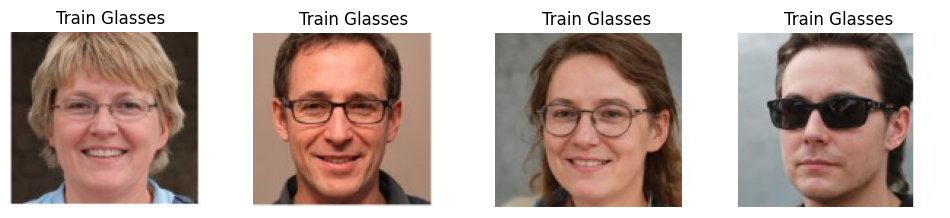

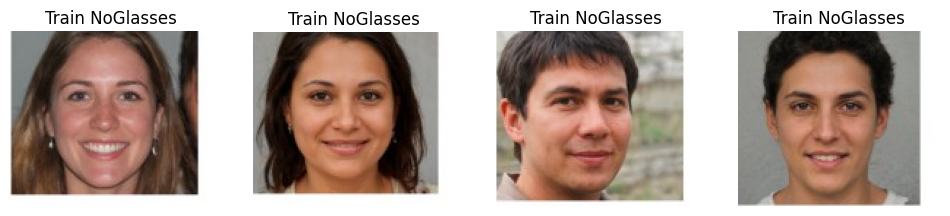

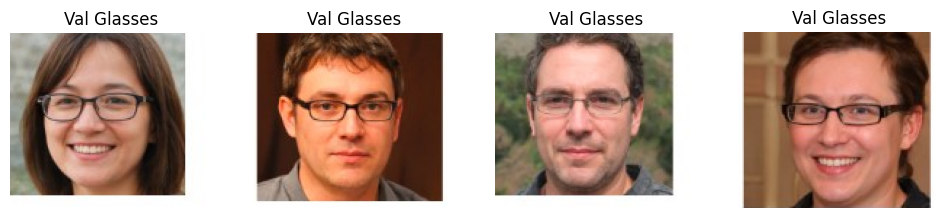

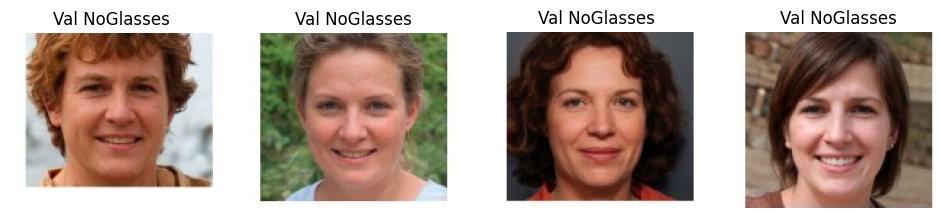

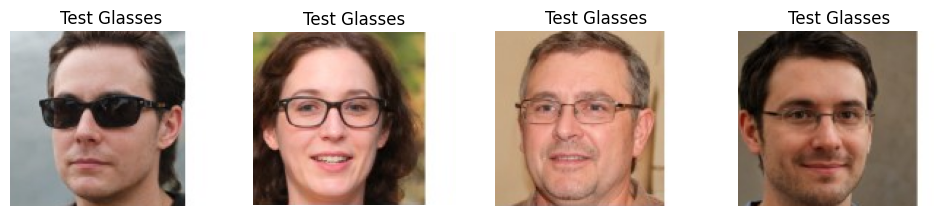

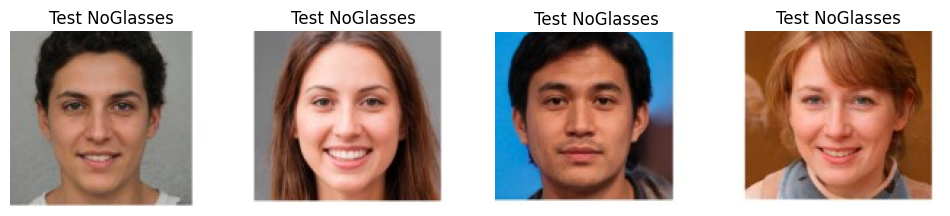

<BarContainer object of 6 artists>

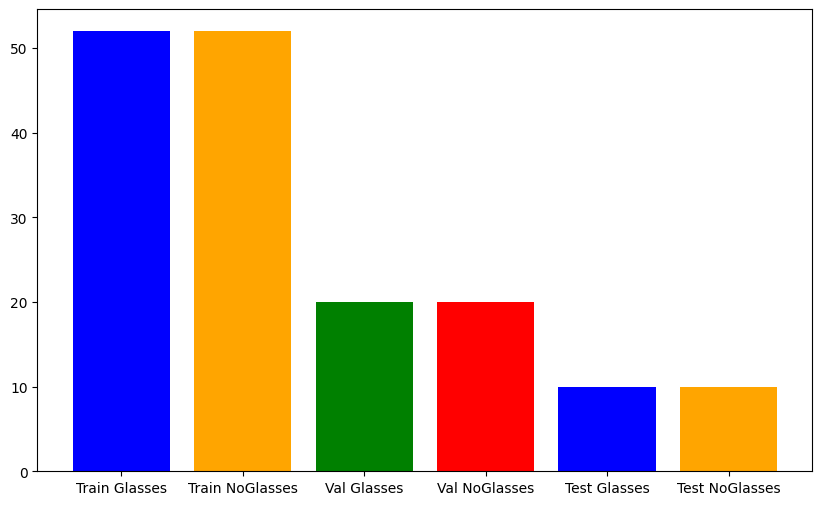

In [11]:
# 이미지와 바 그래프 출력
categories = ['Train Glasses', 'Train NoGlasses', 'Val Glasses', 'Val NoGlasses', 'Test Glasses', 'Test NoGlasses']

for category in categories:
  image_path = glob.glob(f'/content/glasses_dataset/2/{category.lower().replace(" ","/")}/*')
  display_images_center_crop(image_path, category)

# 바 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(categories, [len(glob.glob(f'/content/glasses_dataset/2/{category.lower().replace(" ","/")}/*')) for category in categories], color =['blue', 'orange', 'green', 'red'])

In [12]:
# 데이터 전처리 정의
transform = transforms.Compose([
    transforms.CenterCrop(128), # 이미지 크롭
    transforms.Resize((224, 224)), # 이미지 크기 조정
    transforms.RandomHorizontalFlip(), # 이미지를 무작위로 수평 뒤집기
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # 이미지의 밝기, 대비, 채도, 색조를 무작위로 변경
    transforms.RandomGrayscale(p=0.2), # 20% 확률로 이미지를 그레이스케일로 변환
    transforms.ToTensor(), # 이미지를 텐서로 변환
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # 정규화
])

# 데이터셋 로드 및 데이터 로더 생성
train_dataset = ImageFolder('/content/glasses_dataset/2/train',transform=transform)
val_dataset = ImageFolder('/content/glasses_dataset/2/val', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class AlexNet(nn.Module):
  def __init__(self, num_classes=1000): # ImageNet 데이터셋의 클래스 수는 1000
    super(AlexNet, self).__init__()
    # Convolutional Layer
    self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2)
    self.conv2 = nn.Conv2d(96, 254, kernel_size=5, padding=2)
    self.conv3 = nn.Conv2d(254, 384, kernel_size=3, padding=1)
    self.conv4 = nn.Conv2d(384, 384, kernel_size=3, padding=1)
    self.conv5 = nn.Conv2d(384, 256, kernel_size=3, padding=1)
    # Max Polling layer
    self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2)
    # Fully connected layer
    self.fc1 = nn.Linear(256 * 6 * 6, 4096) # 여기서 6*6은 입력 이미지 크기에 따라 달라질 수 있음 (ex. input Image 224 x 224)
    self.fc2 = nn.Linear(4096, 4096)
    self.fc3 = nn.Linear(4096, num_classes)
    # Drop out
    self.dropout = nn.Dropout()

  def forward(self, x):
    x = self.maxpool(F.relu(self.conv1(x)))
    x = self.maxpool(F.relu(self.conv2(x)))
    x = F.relu(self.conv3(x))
    x = F.relu(self.conv4(x))
    x = self.maxpool(F.relu(self.conv5(x)))
    # Flatten
    x = x.view(x.size(0), 256 * 6 * 6) # 배치 차원 유지하면서 Flatten
    x = self.dropout(F.relu(self.fc1(x)))
    x = self.dropout(F.relu(self.fc2(x)))
    x = self.fc3(x) # 최종 출력에는 활성화 함수를 적용하지 않음
    return x

In [14]:
net = AlexNet(num_classes=2)
net = net.to(device)

In [15]:
# 손실 함수 및 최적화기
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.0001)

In [18]:
# 정확도 계산 함수
def calculate_accuracy(loader, model):
  """주어진 데이터 로더에 대한 모델의 정확도를 계산합니다."""
  model.eval() # 모델을 평가 모드로 설정
  correct = 0
  total = 0
  with torch.no_grad():
    for data in loader:
      images, labels = data
      images, labels = images.to(device) , labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data,1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  return 100 * correct / total

In [19]:
# 학습/검증 손실과 검증 정확도를 저장할 리스트
train_losses = []
val_losses = []
val_accuracies = []

# 모델 학습
num_epochs = 20
for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # 매 에포크마다 평균 학습 손실 계산
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)  # 리스트에 추가

    # 검증 손실 계산
    val_loss = 0.0
    net.eval()  # 모델을 평가 모드로 설정
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)  # 리스트에 추가

    # 검증 정확도 계산
    val_accuracy = calculate_accuracy(val_loader, net)
    val_accuracies.append(val_accuracy)  # 리스트에 추가

    print(f'Epoch {epoch + 1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Validation Accuracy: {val_accuracy:.2f}%')

print('Finished Training')

Epoch 1, Train Loss: 0.691626, Val Loss: 0.689160, Validation Accuracy: 50.00%
Epoch 2, Train Loss: 0.535403, Val Loss: 2.081217, Validation Accuracy: 52.50%
Epoch 3, Train Loss: 0.415327, Val Loss: 0.928811, Validation Accuracy: 57.50%
Epoch 4, Train Loss: 0.242858, Val Loss: 1.196161, Validation Accuracy: 70.00%
Epoch 5, Train Loss: 0.147108, Val Loss: 0.304359, Validation Accuracy: 90.00%
Epoch 6, Train Loss: 0.090104, Val Loss: 2.395429, Validation Accuracy: 72.50%
Epoch 7, Train Loss: 0.318317, Val Loss: 0.785543, Validation Accuracy: 80.00%
Epoch 8, Train Loss: 0.041990, Val Loss: 1.392084, Validation Accuracy: 82.50%
Epoch 9, Train Loss: 0.036979, Val Loss: 0.933813, Validation Accuracy: 90.00%
Epoch 10, Train Loss: 0.060290, Val Loss: 2.958852, Validation Accuracy: 60.00%
Epoch 11, Train Loss: 0.092709, Val Loss: 0.912272, Validation Accuracy: 92.50%
Epoch 12, Train Loss: 0.143373, Val Loss: 1.094105, Validation Accuracy: 85.00%
Epoch 13, Train Loss: 0.036026, Val Loss: 0.98040

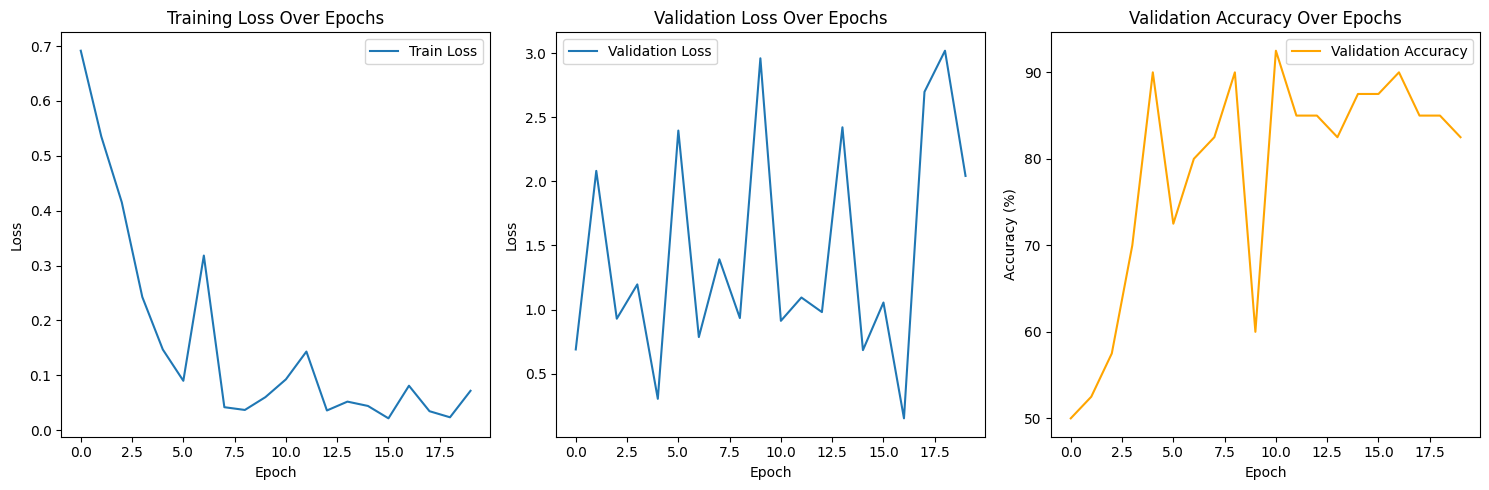

In [20]:
# 학습 손실과 검증 정확도 그래프 그리기
plt.figure(figsize=(15, 5))

# 학습 손실 그래프
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# 검증 정확도 그래프
plt.subplot(1, 3, 2)
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()

# 검증 정확도 그래프
plt.subplot(1, 3, 3)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
def load_and_transform_image(image_path, transform):
    image = Image.open(image_path).convert('RGB')
    width, height = image.size

    # 중앙에서 128x128 크기로 크롭하기 위한 시작점과 끝점 계산
    left = (width - 128) / 2
    top = (height - 128) / 2
    right = (width + 128) / 2
    bottom = (height + 128) / 2

    # 계산된 위치를 기반으로 이미지 크롭
    image_cropped = image.crop((left, top, right, bottom))

    # 크롭된 이미지에 추가 변환 적용 (예: 크기 조정, 텐서 변환, 정규화 등)
    return transform(image_cropped), image_cropped



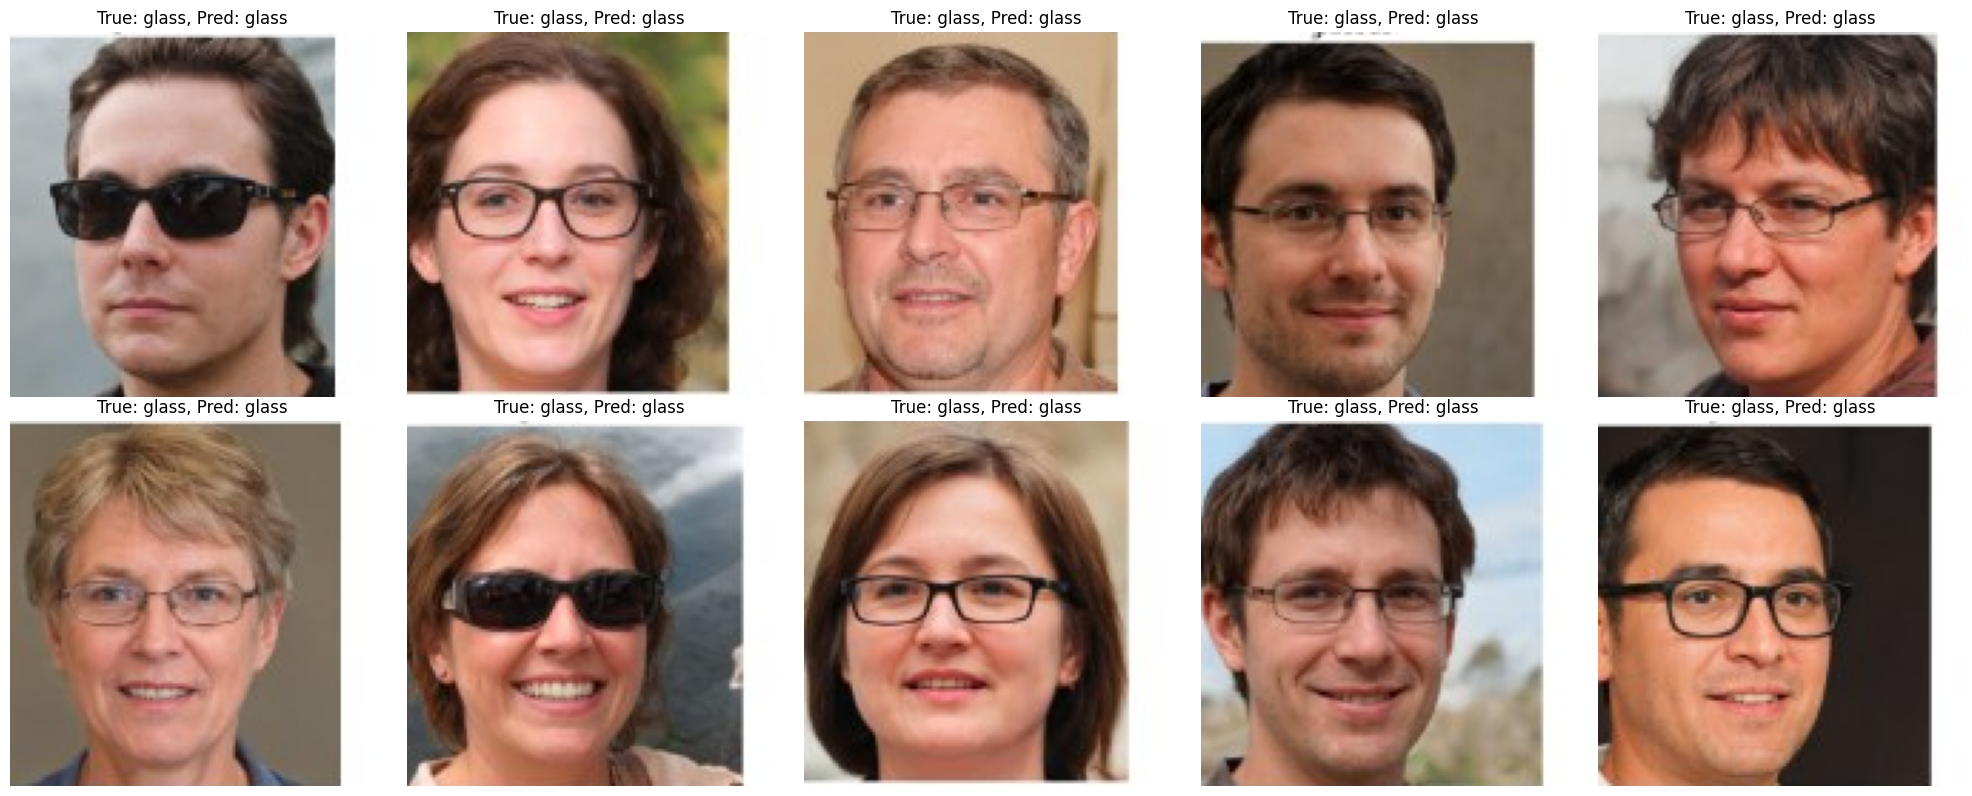

In [24]:
# 클래스별 폴더 경로
class_folders = {
    'glass' : '/content/glasses_dataset/2/test/glasses',
    'no_glass' : '/content/glasses_dataset/2/test/no_glasses'
}

# 각 클래스별로 5장의 이미지 추론 및 시각화
plt.figure(figsize=(20, 8))

# subplot 인덱스를 위한 카운터
counter = 1

for class_name, folder_path in class_folders.items():
    # 해당 클래스의 이미지 경로 가져오기
    image_paths = glob.glob(os.path.join(folder_path, '*'))
    selected_paths = image_paths[:10]  # 첫 5장 선택

    for image_path in selected_paths:
        image, image_cropped = load_and_transform_image(image_path, transform)
        image_unsqueeze = image.unsqueeze(0)  # 배치 차원 추가
        image_unsqueeze = image_unsqueeze.to(device)
        # 모델을 사용한 추론
        output = net(image_unsqueeze)
        _, predicted = torch.max(output, 1)
        prediction = 'glass' if predicted.item() == 0 else 'no glass'

        # 결과 시각화
        plt.subplot(2, 5, counter)
        plt.imshow(image_cropped)
        plt.title(f'True: {class_name}, Pred: {prediction}')
        plt.axis('off')

        counter += 1  # subplot 인덱스 업데이트

plt.tight_layout()
plt.show()